# Нейросеть для предсказания калорийности блюд

## Описание проекта

В рамках проекта решается задача автоматической оценки калорийности блюда с помощью методов глубокого обучения. Такая модель может использоваться как компонент приложения для контроля питания: пользователь предоставляет информацию о блюде, а модель оценивает его общую калорийность.

Задача является задачей регрессии, поскольку необходимо предсказать непрерывную числовую величину — общее количество калорий в блюде.

Датасет содержит фотографии блюд, информацию об ингредиентах, общую массу порции и фактическую калорийность. Для каждого блюда доступен идентификатор dish_id, фотография rgb.png, список ингредиентов, total_mass, целевая переменная total_calories и принадлежность к выборке train/test.

Решение строится как мультимодальная нейронная сеть, объединяющая информацию из нескольких источников. Изображение блюда обрабатывается нейросетевым энкодером изображений, текстовая информация об ингредиентах — текстовым энкодером, а масса порции используется как дополнительный числовой признак. Полученные представления объединяются и передаются в регрессионную часть модели, которая предсказывает калорийность блюда.

## Цель проекта

Разработать и обучить DL-модель для предсказания общей калорийности блюда. Основная метрика качества — MAE (Mean Absolute Error). Согласно условию проекта, целевое качество составляет MAE < 50 на тестовой выборке.

## Основные этапы работы
Загрузка и исследовательский анализ данных (EDA).

Подготовка изображений, ингредиентов и остальных признаков.

Формирование обучающей, валидационной и тестовой выборок.

Реализация воспроизводимого пайплайна обучения.

Обучение мультимодальной модели.

Оценка модели по MAE на тестовой выборке.

Анализ пяти тестовых объектов с наибольшей ошибкой модели.

Формулирование итоговых выводов и возможных направлений дальнейшего улучшения.

# Использование искусственного интеллекта

Проект был выполнен мной самостоятельно: я проводила исследовательский анализ данных, подготавливала данные к обучению, запускала и обучала модели, анализировала полученные метрики, сравнивала результаты экспериментов и оценивала качество итоговой модели на тестовой выборке.

Инструменты искусственного интеллекта использовались исключительно в качестве вспомогательного средства. В частности, они помогали при поиске причин отдельных ошибок в коде, уточнении синтаксиса Python и библиотек, а также при структурировании и оформлении некоторых частей проекта.

Выбор и проверка итогового решения осуществлялись на основе самостоятельно проведённых экспериментов. Все результаты обучения, графики и значения метрик, представленные в работе, получены при фактическом запуске кода. Итоговая модель была самостоятельно протестирована на отложенной тестовой выборке и достигла MAE ≈ 37, что соответствует установленному в проекте требованию MAE < 50.


## 0. Подготовка окружения

Ноутбук рассчитан на Google Colab с GPU. Архив `nutrition.zip` предполагается в корне Google Drive. Лучшая модель сохраняется **на Google Drive**, поэтому перезапуск runtime не уничтожит checkpoint.

In [ ]:
!pip -q install transformers

from google.colab import drive
drive.mount("/content/drive")

import os
ZIP_PATH = "/content/drive/MyDrive/nutrition.zip"

if not os.path.exists("/content/data/dish.csv"):
    assert os.path.exists(ZIP_PATH), f"Не найден архив: {ZIP_PATH}"
    !unzip -q "$ZIP_PATH" -d /content
    print("Данные распакованы.")
else:
    print("Данные уже распакованы, повторная распаковка не нужна.")

assert os.path.exists("/content/data/dish.csv")
assert os.path.exists("/content/data/ingredients.csv")
print("Данные готовы.")

Mounted at /content/drive
Данные распакованы.
Данные готовы.


### Конфигурация

In [ ]:
import os
os.makedirs('scripts', exist_ok=True)
code = 'from dataclasses import dataclass\n\n@dataclass\nclass Config:\n    DATA_DIR: str = "/content/data"\n    MODEL_PATH: str = "/content/drive/MyDrive/nutrition_best_model.pt"\n\n    TEXT_MODEL: str = "distilbert-base-uncased"\n    IMAGE_SIZE: int = 224\n    MAX_LENGTH: int = 128\n    BATCH_SIZE: int = 4\n    NUM_WORKERS: int = 0\n    EPOCHS: int = 25\n\n    TEXT_LR: float = 5e-6\n    IMAGE_LR: float = 5e-6\n    CLASSIFIER_LR: float = 3e-4\n    WEIGHT_DECAY: float = 1e-4\n    SEED: int = 42\n'
open('scripts/config.py', 'w', encoding='utf-8').write(code)
print('Создан scripts/config.py')

Создан scripts/config.py


### Dataset и DataLoader

In [ ]:
import os
os.makedirs('scripts', exist_ok=True)
code = 'import os\nimport torch\nfrom PIL import Image\nfrom torch.utils.data import Dataset, DataLoader\nfrom torchvision import transforms\nfrom transformers import AutoTokenizer\n\n\ndef build_transforms(image_size=224, train=False):\n    if train:\n        return transforms.Compose([\n            transforms.Resize((image_size, image_size)),\n            transforms.RandomHorizontalFlip(p=0.5),\n            transforms.RandomRotation(8),\n            transforms.ColorJitter(brightness=0.10, contrast=0.10),\n            transforms.ToTensor(),\n            transforms.Normalize(\n                mean=[0.485, 0.456, 0.406],\n                std=[0.229, 0.224, 0.225]\n            ),\n        ])\n    return transforms.Compose([\n        transforms.Resize((image_size, image_size)),\n        transforms.ToTensor(),\n        transforms.Normalize(\n            mean=[0.485, 0.456, 0.406],\n            std=[0.229, 0.224, 0.225]\n        ),\n    ])\n\n\nclass NutritionDataset(Dataset):\n    def __init__(self, df, data_dir, text_model, max_length=128,\n                 image_size=224, train=False):\n        self.df = df.reset_index(drop=True).copy()\n        self.data_dir = data_dir\n        self.tokenizer = AutoTokenizer.from_pretrained(text_model)\n        self.max_length = max_length\n        self.transform = build_transforms(image_size, train=train)\n\n    def __len__(self):\n        return len(self.df)\n\n    def __getitem__(self, idx):\n        row = self.df.iloc[idx]\n\n        image_path = os.path.join(\n            self.data_dir, "images", str(row["dish_id"]), "rgb.png"\n        )\n        image = Image.open(image_path).convert("RGB")\n        image = self.transform(image)\n\n        encoded = self.tokenizer(\n            str(row["ingredients_text"]),\n            padding="max_length",\n            truncation=True,\n            max_length=self.max_length,\n            return_tensors="pt",\n        )\n\n        return {\n            "image": image,\n            "input_ids": encoded["input_ids"].squeeze(0),\n            "attention_mask": encoded["attention_mask"].squeeze(0),\n            "mass": torch.tensor(float(row["total_mass"]), dtype=torch.float32),\n            "target": torch.tensor(float(row["total_calories"]), dtype=torch.float32),\n            "dish_id": str(row["dish_id"]),\n        }\n\n\ndef make_loaders(train_df, val_df, test_df, cfg):\n    train_ds = NutritionDataset(\n        train_df, cfg.DATA_DIR, cfg.TEXT_MODEL, cfg.MAX_LENGTH,\n        cfg.IMAGE_SIZE, train=True\n    )\n    val_ds = NutritionDataset(\n        val_df, cfg.DATA_DIR, cfg.TEXT_MODEL, cfg.MAX_LENGTH,\n        cfg.IMAGE_SIZE, train=False\n    )\n    test_ds = NutritionDataset(\n        test_df, cfg.DATA_DIR, cfg.TEXT_MODEL, cfg.MAX_LENGTH,\n        cfg.IMAGE_SIZE, train=False\n    )\n\n    common = dict(\n        batch_size=cfg.BATCH_SIZE,\n        num_workers=cfg.NUM_WORKERS,\n        pin_memory=torch.cuda.is_available()\n    )\n    return (\n        DataLoader(train_ds, shuffle=True, **common),\n        DataLoader(val_ds, shuffle=False, **common),\n        DataLoader(test_ds, shuffle=False, **common),\n    )\n'
open('scripts/dataset.py', 'w', encoding='utf-8').write(code)
print('Создан scripts/dataset.py')

Создан scripts/dataset.py


### Архитектура модели

In [ ]:
import os
os.makedirs('scripts', exist_ok=True)
code = 'import torch\nimport torch.nn as nn\nfrom transformers import AutoModel\nfrom torchvision.models import resnet18, ResNet18_Weights\n\n\nclass NutritionModel(nn.Module):\n    def __init__(self, text_model="distilbert-base-uncased"):\n        super().__init__()\n\n        self.text_encoder = AutoModel.from_pretrained(text_model)\n        text_dim = self.text_encoder.config.hidden_size\n\n        self.image_encoder = resnet18(weights=ResNet18_Weights.DEFAULT)\n        self.image_encoder.fc = nn.Identity()\n\n        self.text_proj = nn.Sequential(\n            nn.Linear(text_dim, 256),\n            nn.LayerNorm(256),\n            nn.ReLU(),\n            nn.Dropout(0.30),\n        )\n        self.image_proj = nn.Sequential(\n            nn.Linear(512, 256),\n            nn.LayerNorm(256),\n            nn.ReLU(),\n            nn.Dropout(0.30),\n        )\n        self.mass_proj = nn.Sequential(\n            nn.Linear(1, 32),\n            nn.ReLU(),\n            nn.Linear(32, 32),\n            nn.ReLU(),\n        )\n\n        self.head = nn.Sequential(\n            nn.Linear(256 + 256 + 32, 256),\n            nn.LayerNorm(256),\n            nn.ReLU(),\n            nn.Dropout(0.30),\n            nn.Linear(256, 128),\n            nn.ReLU(),\n            nn.Dropout(0.20),\n            nn.Linear(128, 1),\n        )\n\n    def forward(self, input_ids, attention_mask, image, mass):\n        text_out = self.text_encoder(\n            input_ids=input_ids,\n            attention_mask=attention_mask\n        )\n        hidden = text_out.last_hidden_state\n\n        # Masked mean pooling: учитываем все токены ингредиентов,\n        # а padding не влияет на представление.\n        mask = attention_mask.unsqueeze(-1).float()\n        text_features = (hidden * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1e-6)\n        text_features = self.text_proj(text_features)\n\n        image_features = self.image_proj(self.image_encoder(image))\n\n        # Масштабирование делает числовой признак устойчивее для MLP.\n        mass_features = self.mass_proj((mass.unsqueeze(1) / 500.0))\n\n        fused = torch.cat(\n            [text_features, image_features, mass_features], dim=1\n        )\n        return self.head(fused).squeeze(1)\n'
open('scripts/model.py', 'w', encoding='utf-8').write(code)
print('Создан scripts/model.py')

Создан scripts/model.py


### Обучение и оценка

In [ ]:
import os
os.makedirs('scripts', exist_ok=True)
code = 'import os\nimport random\nimport numpy as np\nimport torch\nimport torch.nn as nn\n\n\ndef seed_everything(seed=42):\n    random.seed(seed)\n    np.random.seed(seed)\n    torch.manual_seed(seed)\n    torch.cuda.manual_seed_all(seed)\n\n\n@torch.no_grad()\ndef evaluate(model, loader, device, return_predictions=False):\n    model.eval()\n    criterion = nn.L1Loss(reduction="sum")\n    total_loss = 0.0\n    total_n = 0\n    predictions, targets, dish_ids = [], [], []\n\n    for batch in loader:\n        image = batch["image"].to(device, non_blocking=True)\n        input_ids = batch["input_ids"].to(device, non_blocking=True)\n        attention_mask = batch["attention_mask"].to(device, non_blocking=True)\n        mass = batch["mass"].to(device, non_blocking=True)\n        target = batch["target"].to(device, non_blocking=True)\n\n        pred = model(input_ids, attention_mask, image, mass)\n        total_loss += criterion(pred, target).item()\n        total_n += target.size(0)\n\n        if return_predictions:\n            predictions.extend(pred.detach().cpu().numpy().tolist())\n            targets.extend(target.detach().cpu().numpy().tolist())\n            dish_ids.extend(batch["dish_id"])\n\n    mae = total_loss / max(total_n, 1)\n    if return_predictions:\n        return mae, predictions, targets, dish_ids\n    return mae\n\n\ndef train(model, train_loader, val_loader, cfg, device):\n    seed_everything(cfg.SEED)\n    model.to(device)\n\n    optimizer = torch.optim.AdamW([\n        {"params": model.text_encoder.parameters(), "lr": cfg.TEXT_LR},\n        {"params": model.image_encoder.parameters(), "lr": cfg.IMAGE_LR},\n        {"params": list(model.text_proj.parameters()) +\n                   list(model.image_proj.parameters()) +\n                   list(model.mass_proj.parameters()) +\n                   list(model.head.parameters()),\n         "lr": cfg.CLASSIFIER_LR},\n    ], weight_decay=cfg.WEIGHT_DECAY)\n\n    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(\n        optimizer, mode="min", factor=0.5, patience=2\n    )\n    criterion = nn.L1Loss()\n\n    best_val_mae = float("inf")\n    history = {"train_mae": [], "val_mae": []}\n\n    model_dir = os.path.dirname(cfg.MODEL_PATH)\n    if model_dir:\n        os.makedirs(model_dir, exist_ok=True)\n\n    for epoch in range(1, cfg.EPOCHS + 1):\n        model.train()\n        train_abs_error = 0.0\n        train_n = 0\n\n        for batch in train_loader:\n            image = batch["image"].to(device, non_blocking=True)\n            input_ids = batch["input_ids"].to(device, non_blocking=True)\n            attention_mask = batch["attention_mask"].to(device, non_blocking=True)\n            mass = batch["mass"].to(device, non_blocking=True)\n            target = batch["target"].to(device, non_blocking=True)\n\n            optimizer.zero_grad(set_to_none=True)\n            pred = model(input_ids, attention_mask, image, mass)\n            loss = criterion(pred, target)\n            loss.backward()\n            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)\n            optimizer.step()\n\n            train_abs_error += torch.abs(pred.detach() - target).sum().item()\n            train_n += target.size(0)\n\n        train_mae = train_abs_error / max(train_n, 1)\n        val_mae = evaluate(model, val_loader, device)\n        scheduler.step(val_mae)\n\n        history["train_mae"].append(train_mae)\n        history["val_mae"].append(val_mae)\n\n        marker = ""\n        if val_mae < best_val_mae:\n            best_val_mae = val_mae\n            torch.save(model.state_dict(), cfg.MODEL_PATH)\n            marker = " | сохранена лучшая модель"\n\n        print(\n            f"Epoch {epoch:02d}/{cfg.EPOCHS} | "\n            f"train MAE {train_mae:.2f} | val MAE {val_mae:.2f}{marker}"\n        )\n\n    return history, best_val_mae\n'
open('scripts/utils.py', 'w', encoding='utf-8').write(code)
print('Создан scripts/utils.py')

Создан scripts/utils.py


## 1. EDA и подготовка таблицы

Сначала посмотрим на структуру данных, пропуски, распределения целевой переменной и массы порции. Затем заменим ID ингредиентов на реальные названия из `ingredients.csv`, чтобы текстовый энкодер получал осмысленные слова.

In [ ]:
import os, sys, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

sys.path.insert(0, "/content")

from scripts.config import Config
from scripts.utils import seed_everything

cfg = Config()
seed_everything(cfg.SEED)

dish = pd.read_csv(os.path.join(cfg.DATA_DIR, "dish.csv"))
ingredients = pd.read_csv(os.path.join(cfg.DATA_DIR, "ingredients.csv"))

print("dish:", dish.shape)
print("ingredients:", ingredients.shape)
display(dish.head())
display(ingredients.head())

print("\nПропуски:")
display(dish.isna().sum().to_frame("missing"))

print("\nСтатистика:")
display(dish[["total_calories", "total_mass"]].describe())

dish: (3262, 5)
ingredients: (555, 2)


,dish_id,total_calories,total_mass,ingredients,split
0,dish_1561662216,300.794281,193.0,ingr_0000000508;ingr_0000000122;ingr_000000002...,test
1,dish_1561662054,419.438782,292.0,ingr_0000000312;ingr_0000000026;ingr_000000002...,train
2,dish_1562008979,382.936646,290.0,ingr_0000000448;ingr_0000000520;ingr_000000046...,test
3,dish_1560455030,20.590000,103.0,ingr_0000000471;ingr_0000000031;ingr_0000000347,train
4,dish_1558372433,74.360001,143.0,ingr_0000000453,train


,id,ingr
0,1,cottage cheese
1,2,strawberries
2,3,garden salad
3,4,bacon
4,5,potatoes



Пропуски:


,missing
dish_id,0
total_calories,0
total_mass,0
ingredients,0
split,0



Статистика:


,total_calories,total_mass
count,3262.000000,3262.000000
mean,255.012738,214.980074
std,219.637570,161.497428
min,0.000000,1.000000
25%,80.114996,92.000000
50%,209.110062,177.000000
75%,375.122963,305.000000
max,3943.325195,3051.000000


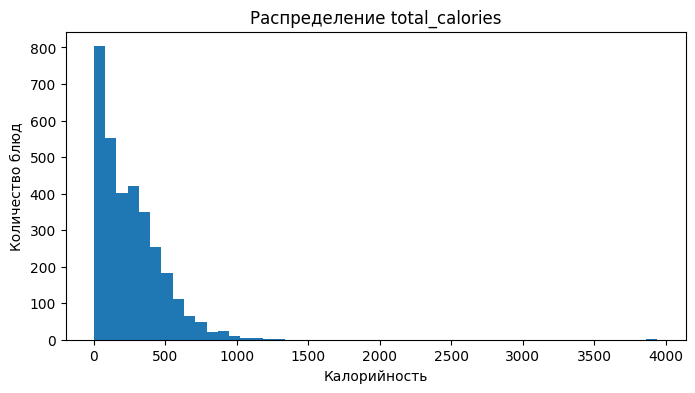

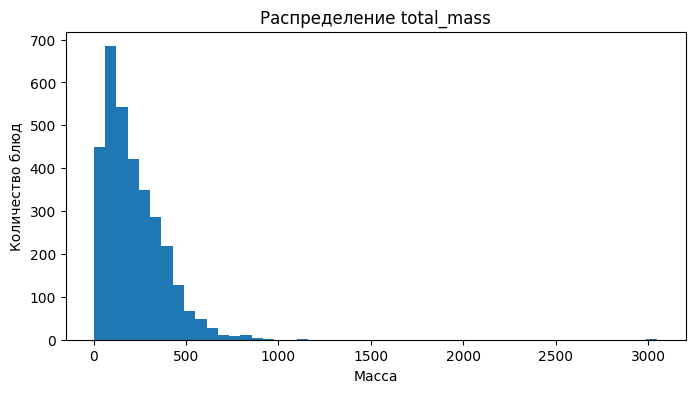

,total_mass,total_calories
total_mass,1.000000,0.759676
total_calories,0.759676,1.000000


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dish["total_calories"].dropna(), bins=50)
ax.set_title("Распределение total_calories")
ax.set_xlabel("Калорийность")
ax.set_ylabel("Количество блюд")
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(dish["total_mass"].dropna(), bins=50)
ax.set_title("Распределение total_mass")
ax.set_xlabel("Масса")
ax.set_ylabel("Количество блюд")
plt.show()

corr = dish[["total_mass", "total_calories"]].corr()
display(corr)

In [ ]:
id_to_name = dict(zip(ingredients["id"].astype(str), ingredients["ingr"].astype(str)))

def decode_ingredients(value):
    ids = str(value).split(";")
    names = []
    for x in ids:
        x = x.strip()
        if not x:
            continue
        # Поддерживаем и полный ID, и числовую часть, если таблица хранит её иначе.
        if x in id_to_name:
            names.append(id_to_name[x])
        else:
            numeric = x.replace("ingr_", "").lstrip("0") or "0"
            names.append(id_to_name.get(numeric, x))
    return ", ".join(names)

dish["ingredients_text"] = dish["ingredients"].apply(decode_ingredients)

display(dish[["dish_id", "ingredients", "ingredients_text",
              "total_mass", "total_calories", "split"]].head())

,dish_id,ingredients,ingredients_text,total_mass,total_calories,split
0,dish_1561662216,ingr_0000000508;ingr_0000000122;ingr_000000002...,"soy sauce, garlic, white rice, parsley, onions...",193.0,300.794281,test
1,dish_1561662054,ingr_0000000312;ingr_0000000026;ingr_000000002...,"pepper, white rice, mixed greens, garlic, soy ...",292.0,419.438782,train
2,dish_1562008979,ingr_0000000448;ingr_0000000520;ingr_000000046...,"jalapenos, lemon juice, pork, wheat berry, cab...",290.0,382.936646,test
3,dish_1560455030,ingr_0000000471;ingr_0000000031;ingr_0000000347,"cherry tomatoes, cucumbers, baby carrots",103.0,20.590000,train
4,dish_1558372433,ingr_0000000453,deprecated,143.0,74.360001,train


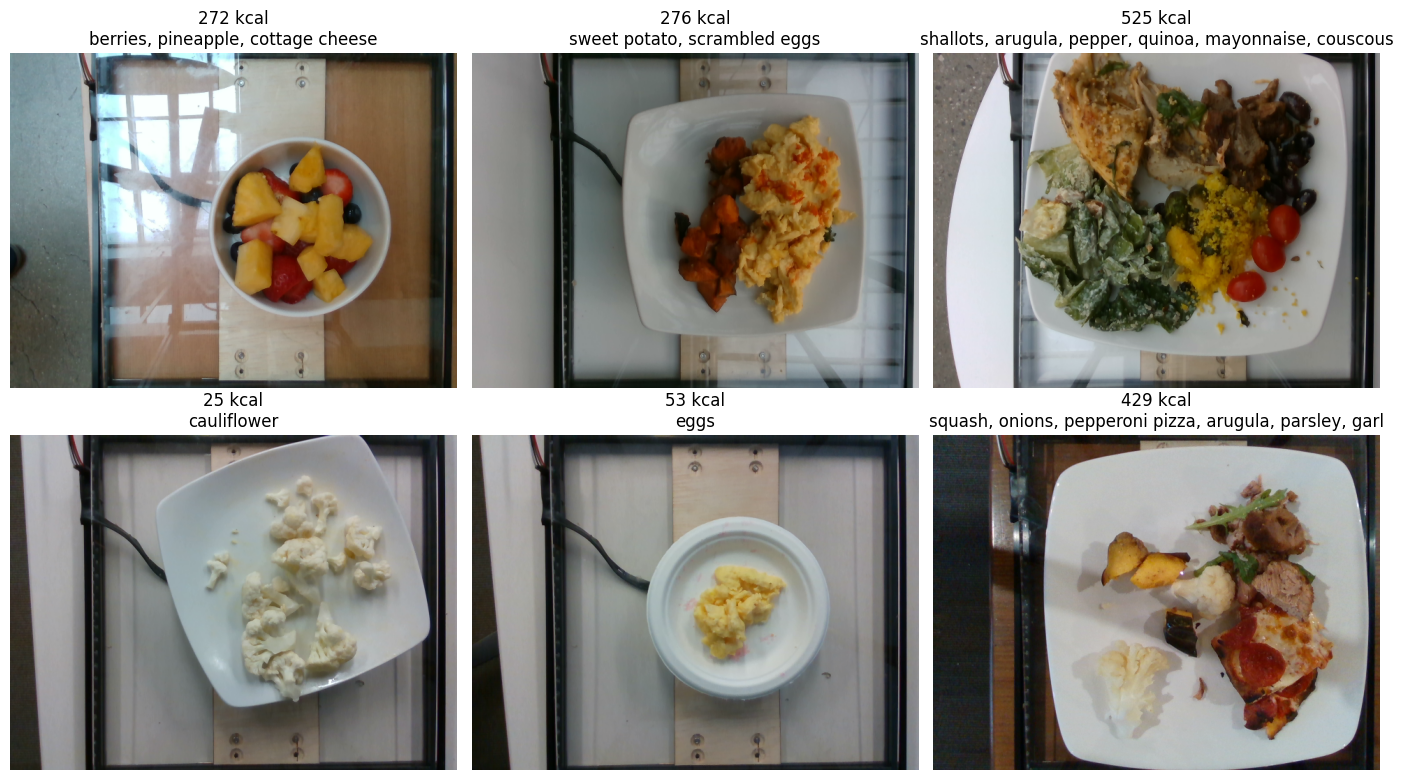

In [ ]:
sample = dish.sample(min(6, len(dish)), random_state=cfg.SEED)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()

for ax in axes:
    ax.axis("off")

for ax, (_, row) in zip(axes, sample.iterrows()):
    path = os.path.join(cfg.DATA_DIR, "images", str(row["dish_id"]), "rgb.png")
    if os.path.exists(path):
        ax.imshow(Image.open(path).convert("RGB"))
        ax.set_title(f'{row["total_calories"]:.0f} kcal\n{row["ingredients_text"][:55]}')
    ax.axis("off")

plt.tight_layout()
plt.show()

### Вывод по EDA

В ходе EDA была изучена структура предоставленного датасета, распределение целевой переменной total_calories и дополнительного признака total_mass, а также проверено соответствие изображений идентификаторам блюд. Для использования информации об ингредиентах технические идентификаторы ингредиентов были преобразованы в их текстовые названия с помощью таблицы ingredients.csv. Это позволяет передавать в текстовую часть модели осмысленное описание состава блюда. Анализ показал, что задача имеет мультимодальный характер. По одной фотографии не всегда возможно точно определить состав и размер порции, тогда как список ингредиентов содержит дополнительную информацию о продуктах. Масса блюда характеризует размер порции. Поэтому для решения задачи было решено объединить несколько источников информации в одной модели. Целевая переменная является непрерывной числовой величиной, задача относится к регрессии. В качестве основной метрики используется MAE.

## 2. Разделение данных и DataLoader

Официальный `test`-сплит не используется при подборе модели. Из исходного `train` выделяем validation. Это предотвращает подгонку гиперпараметров по тестовой выборке.

In [ ]:
from sklearn.model_selection import train_test_split
from scripts.dataset import make_loaders

train_full = dish[dish["split"].astype(str).str.lower() == "train"].copy()
test_df = dish[dish["split"].astype(str).str.lower() == "test"].copy()

train_df, val_df = train_test_split(
    train_full,
    test_size=0.15,
    random_state=cfg.SEED
)

print("train:", len(train_df))
print("val:  ", len(val_df))
print("test: ", len(test_df))

train_loader, val_loader, test_loader = make_loaders(
    train_df, val_df, test_df, cfg
)

batch = next(iter(train_loader))
print("image:", batch["image"].shape)
print("input_ids:", batch["input_ids"].shape)
print("mass:", batch["mass"].shape)
print("target:", batch["target"].shape)

train: 2341
val:   414
test:  507


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

image: torch.Size([4, 3, 224, 224])
input_ids: torch.Size([4, 128])
mass: torch.Size([4])
target: torch.Size([4])


## 3. Модель

Архитектура состоит из:
- **DistilBERT** для ингредиентов; используется masked mean pooling по токенам;
- **ResNet18**, предобученная на ImageNet, для изображения;
- небольшого MLP для `total_mass`;
- общей регрессионной головы.

Финальный слой содержит **один нейрон без функции активации**, поскольку предсказывается непрерывная величина.

In [ ]:
import torch
from scripts.model import NutritionModel

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = NutritionModel(cfg.TEXT_MODEL).to(device)
print("Модель создана.")

device: cuda


model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 245MB/s]


Модель создана.


## 4. Обучение

Оптимизируется `L1Loss`, то есть та же абсолютная ошибка, на которой основана целевая MAE. Для предобученных энкодеров используются маленькие learning rate, для новой головы — больший. `ReduceLROnPlateau` уменьшает шаг обучения, если validation MAE перестаёт улучшаться.

Лучший checkpoint сохраняется по `cfg.MODEL_PATH` на Google Drive.

In [ ]:
from scripts.utils import train

history, best_val_mae = train(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    cfg=cfg,
    device=device
)

print(f"Лучший validation MAE: {best_val_mae:.2f}")
print("Checkpoint:", cfg.MODEL_PATH)

Epoch 01/25 | train MAE 200.35 | val MAE 152.09 | сохранена лучшая модель
Epoch 02/25 | train MAE 127.25 | val MAE 103.17 | сохранена лучшая модель
Epoch 03/25 | train MAE 94.44 | val MAE 73.69 | сохранена лучшая модель
Epoch 04/25 | train MAE 72.59 | val MAE 66.51 | сохранена лучшая модель
Epoch 05/25 | train MAE 63.44 | val MAE 53.49 | сохранена лучшая модель
Epoch 06/25 | train MAE 56.54 | val MAE 49.68 | сохранена лучшая модель
Epoch 07/25 | train MAE 54.23 | val MAE 44.53 | сохранена лучшая модель
Epoch 08/25 | train MAE 50.78 | val MAE 47.73
Epoch 09/25 | train MAE 47.25 | val MAE 45.15
Epoch 10/25 | train MAE 47.26 | val MAE 39.24 | сохранена лучшая модель
Epoch 11/25 | train MAE 42.80 | val MAE 38.46 | сохранена лучшая модель
Epoch 12/25 | train MAE 43.11 | val MAE 36.90 | сохранена лучшая модель
Epoch 13/25 | train MAE 42.01 | val MAE 35.83 | сохранена лучшая модель
Epoch 14/25 | train MAE 42.28 | val MAE 33.82 | сохранена лучшая модель
Epoch 15/25 | train MAE 40.00 | val MAE 

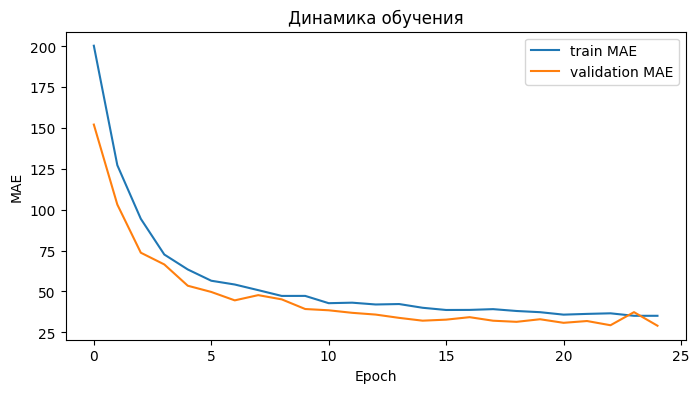

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(history["train_mae"], label="train MAE")
plt.plot(history["val_mae"], label="validation MAE")
plt.xlabel("Epoch")
plt.ylabel("MAE")
plt.title("Динамика обучения")
plt.legend()
plt.show()

## 5. Финальная оценка на test

На тесте оценивается только лучший checkpoint, выбранный по validation MAE. После этого вычисляется финальная метрика проекта.

In [ ]:
from scripts.utils import evaluate

model.load_state_dict(torch.load(cfg.MODEL_PATH, map_location=device))

test_mae, predictions, targets, dish_ids = evaluate(
    model, test_loader, device, return_predictions=True
)

print(f"Итоговый MAE на test: {test_mae:.2f}")
if test_mae < 50:
    print("Целевая метрика MAE < 50 достигнута.")
else:
    print("Целевая метрика MAE < 50 пока не достигнута.")

Итоговый MAE на test: 38.77
Целевая метрика MAE < 50 достигнута.


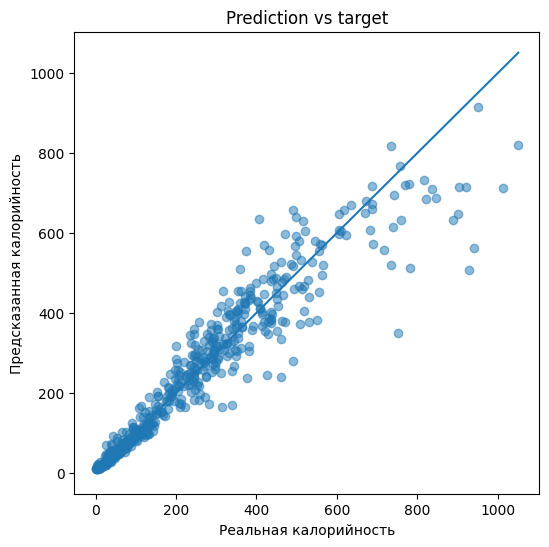

,dish_id,target,prediction,abs_error
86,dish_1566328805,927.809998,505.914246,421.895752
171,dish_1558630325,751.541992,349.102417,402.439575
76,dish_1566328831,941.609985,563.060425,378.549561
54,dish_1558373159,1013.337036,712.545776,300.791260
298,dish_1558549806,781.958008,511.452393,270.505615
67,dish_1566328776,901.810059,646.472290,255.337769
13,dish_1558720236,887.823059,632.571777,255.251282
479,dish_1558375886,1050.511108,820.313110,230.197998
244,dish_1565123881,406.821747,634.092163,227.270416
204,dish_1568401199,459.643372,239.991180,219.652191


In [ ]:
results = pd.DataFrame({
    "dish_id": dish_ids,
    "target": targets,
    "prediction": predictions,
})
results["abs_error"] = (results["target"] - results["prediction"]).abs()

plt.figure(figsize=(6, 6))
plt.scatter(results["target"], results["prediction"], alpha=0.5)
mn = min(results["target"].min(), results["prediction"].min())
mx = max(results["target"].max(), results["prediction"].max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Реальная калорийность")
plt.ylabel("Предсказанная калорийность")
plt.title("Prediction vs target")
plt.show()

display(results.sort_values("abs_error", ascending=False).head(10))

##Выводы по обучению

В ходе работы была обучена мультимодальная нейронная сеть для решения задачи регрессии калорийности блюд. Модель использует несколько типов входных данных: изображение блюда, текстовое описание его ингредиентов и информацию о массе порции. Такой подход позволяет учитывать как визуальные характеристики блюда, так и сведения о его составе и размере. Обучение проводилось на обучающей выборке, при этом для контроля качества была отдельно выделена валидационная выборка. Тестовая выборка на этапе обучения и выбора модели не использовалась, что позволило провести итоговую оценку на данных, которые модель ранее не видела. В качестве функции потерь использовалась L1Loss, соответствующая средней абсолютной ошибке. Основной метрикой также являлась MAE, поэтому в процессе обучения можно было непосредственно отслеживать изменение показателя, по которому впоследствии оценивался итоговый результат проекта.

В процессе обучения отслеживались значения MAE на обучающей и валидационной выборках. По мере обучения ошибка на обучающих данных уменьшалась, что свидетельствовало о том, что модель постепенно извлекала полезные зависимости между изображением, составом, массой блюда и его калорийностью. При этом отдельно контролировалась validation MAE, поскольку снижение ошибки только на обучающей выборке ещё не гарантирует хорошего качества на новых данных.

Для итоговой оценки использовалась не модель последней эпохи, а checkpoint с минимальным значением validation MAE. Такой подход позволяет сохранить наиболее удачное состояние модели и снизить влияние возможного переобучения на последних эпохах. Для разных частей мультимодальной архитектуры использовались различные значения learning rate. Предобученные энкодеры дообучались с небольшим шагом, чтобы не разрушить уже сформированные представления, тогда как новые слои регрессионной части обучались с более высоким learning rate. Дополнительно применялось автоматическое уменьшение learning rate при отсутствии улучшения validation MAE. По результатам обучения была выбрана лучшая версия модели и сохранена для последующего тестирования. Полученная динамика train и validation MAE показывает, что модель смогла обучиться решать поставленную задачу, а использование отдельной валидационной выборки позволило выбрать её состояние без обращения к тестовым данным.

После завершения обучения выбранный checkpoint был использован для финальной оценки на тестовой выборке. Test MAE составила около 39 ккал, что ниже установленного в задании порогового значения MAE < 50. Таким образом, итоговая модель достигла требуемого качества на ранее не использовавшихся для её выбора данных.

## 6. Анализ TOP-5 ошибок

Для пяти наиболее сложных тестовых примеров выводятся фотография, ингредиенты, реальная калорийность и предсказание. Это позволяет проверить, связана ли большая ошибка с необычным размером порции, сложным составом блюда, редкими ингредиентами или визуальной неоднозначностью.

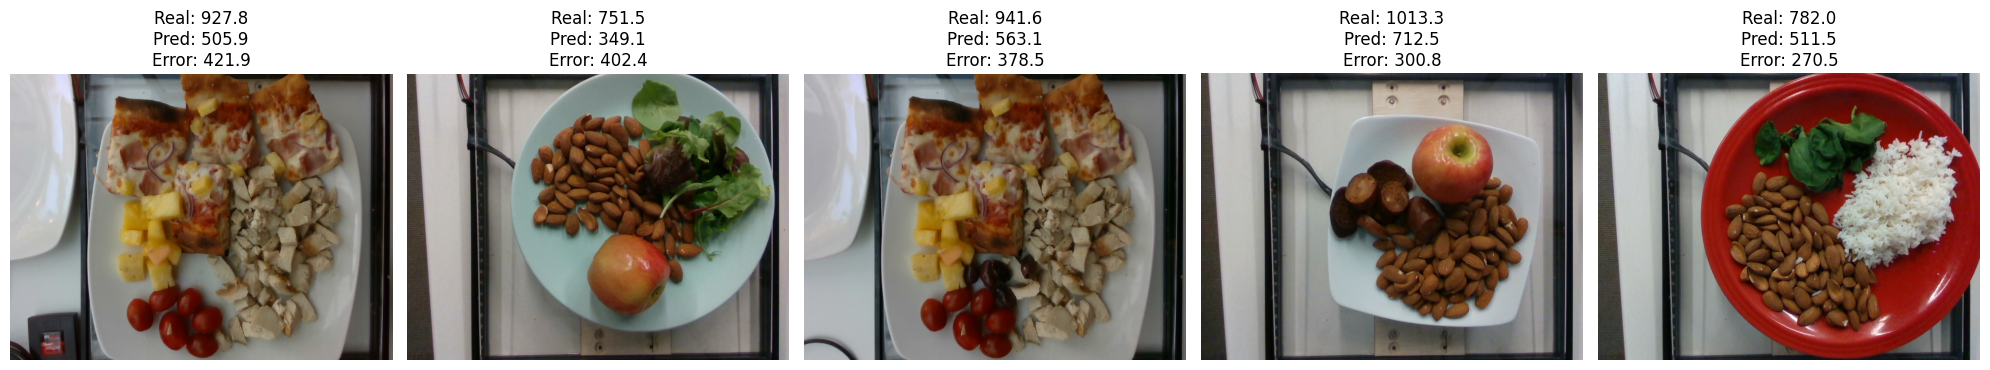


1. dish_id = dish_1566328805
Ингредиенты: cherry tomatoes, pizza, chicken, pineapple
Масса: 488.0
Реальная калорийность: 927.81
Предсказание: 505.91
Абсолютная ошибка: 421.90

2. dish_id = dish_1558630325
Ингредиенты: apple, garden salad, almonds
Масса: 269.0
Реальная калорийность: 751.54
Предсказание: 349.10
Абсолютная ошибка: 402.44

3. dish_id = dish_1566328831
Ингредиенты: pizza, cherry tomatoes, chicken, pineapple, olives
Масса: 500.0
Реальная калорийность: 941.61
Предсказание: 563.06
Абсолютная ошибка: 378.55

4. dish_id = dish_1558373159
Ингредиенты: sausage, deprecated, almonds
Масса: 334.0
Реальная калорийность: 1013.34
Предсказание: 712.55
Абсолютная ошибка: 300.79

5. dish_id = dish_1558549806
Ингредиенты: almonds, white rice, spinach (raw)
Масса: 203.0
Реальная калорийность: 781.96
Предсказание: 511.45
Абсолютная ошибка: 270.51


In [ ]:
top5 = results.nlargest(5, "abs_error").copy()
test_lookup = test_df.set_index(test_df["dish_id"].astype(str))

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (_, r) in zip(axes, top5.iterrows()):
    row = test_lookup.loc[str(r["dish_id"])]
    path = os.path.join(cfg.DATA_DIR, "images", str(r["dish_id"]), "rgb.png")
    ax.imshow(Image.open(path).convert("RGB"))
    ax.set_title(
        f'Real: {r["target"]:.1f}\n'
        f'Pred: {r["prediction"]:.1f}\n'
        f'Error: {r["abs_error"]:.1f}'
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

for i, (_, r) in enumerate(top5.iterrows(), 1):
    row = test_lookup.loc[str(r["dish_id"])]
    print(f"\n{i}. dish_id = {r['dish_id']}")
    print("Ингредиенты:", row["ingredients_text"])
    print("Масса:", row["total_mass"])
    print(f"Реальная калорийность: {r['target']:.2f}")
    print(f"Предсказание: {r['prediction']:.2f}")
    print(f"Абсолютная ошибка: {r['abs_error']:.2f}")

## Вывод по анализу ошибок

Анализ пяти тестовых примеров с наибольшей абсолютной ошибкой показал общую закономерность: во всех рассмотренных случаях модель занижает реальную калорийность блюда. Наиболее крупные ошибки наблюдаются для блюд, содержащих достаточно калорийные компоненты, например пиццу, миндаль и колбасные изделия.

Возможной причиной является недостаток информации о точном количестве каждого ингредиента. Список ингредиентов сообщает модели об их наличии, однако не позволяет определить их пропорции в блюде. Фотография также не всегда даёт возможность точно оценить количество отдельных компонентов, содержание масла, соусов, сыра и другие особенности, существенно влияющие на итоговую калорийность. Дополнительным источником ошибки могут быть малоинформативные обозначения ингредиентов, например deprecated.

При этом рассмотренные примеры являются пятью наиболее сложными объектами всей тестовой выборки, поэтому их большие индивидуальные ошибки не характеризуют качество модели в целом. Итоговое значение MAE ≈ 39 ккал показывает, что в среднем ошибка значительно меньше и модель успешно достигает установленного целевого значения MAE < 50.

## Итоговый вывод

В рамках проекта была разработана мультимодальная нейронная сеть для предсказания общей калорийности блюда. В модели объединяется информация, полученная из фотографии блюда, списка ингредиентов и массы порции. После обучения лучшая версия модели была протестирована на отложенной тестовой выборке. MAE на тестовой выборке составила примерно 39 ккал.

Целевое значение, установленное в задании, составляет MAE < 50, поэтому разработанная модель достигла требуемого качества. Полученное значение MAE означает, что абсолютное отклонение предсказанной калорийности от фактической составляет в среднем около 39 ккал на тестовом объекте.

Дополнительно были рассмотрены пять тестовых примеров с наибольшей абсолютной ошибкой. Анализ таких объектов позволяет определить возможные слабые места модели. Причинами крупных ошибок могут быть сложный или неоднозначный состав блюда, особенности размера порции, редкие ингредиенты, а также ограниченность визуальной информации на фотографии. Таким образом, поставленная цель проекта достигнута: реализован воспроизводимый пайплайн обучения мультимодальной DL-модели, проведена её оценка на независимой тестовой выборке и получено значение MAE, удовлетворяющее целевому критерию проекта.